<a href="https://colab.research.google.com/github/lalit911-gt3/Cryptocurrency-Price-Volatility/blob/main/week%206%20final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Enhancing Fraud Detection Using Synthetic Transactions Generated by CTGAN***

Cell 1: Environment Setup

*First, install the necessary generative AI and machine learning libraries*

In [21]:
!pip install sdv pandas numpy scikit-learn matplotlib seaborn

Cell 2: Imports and Data Loading

*Import your tools and load the Kaggle Credit Card Fraud dataset. Ensure creditcard.csv is uploaded to your Colab session.*

Class Distribution:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


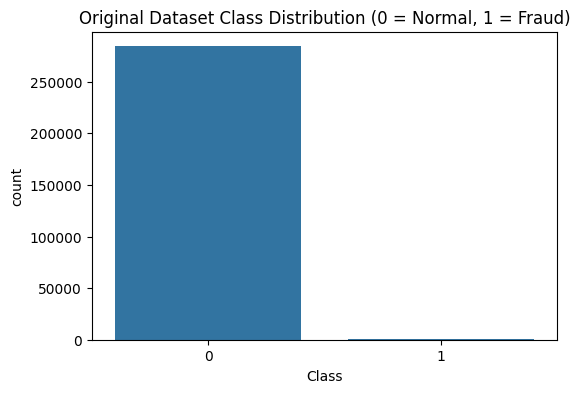

Total Normal Transactions: 284315
Total Fraud Transactions: 492


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
data = pd.read_csv('creditcard.csv')

#Class distribution check
print("Class Distribution:")
print(data['Class'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=data)
plt.title('Original Dataset Class Distribution (0 = Normal, 1 = Fraud)')
plt.show()

#Separate the Fraud and Normal Data
normal_data = data[data['Class'] == 0]
fraud_data = data[data['Class'] == 1]

print(f"Total Normal Transactions: {len(normal_data)}")
print(f"Total Fraud Transactions: {len(fraud_data)}")

Cell 3: Exploratory Data Analysis (EDA)

*This cell combines the class imbalance check, correlation heatmap, and boxplots to understand the data before augmentation.*

In [23]:
!pip install ctgan

Cell 4: Train CTGAN & Generate Synthetic Data

*Isolate the rare fraud events, train the GenAI model to learn their distribution, and generate 5,000 new synthetic samples.*

In [24]:
from ctgan import CTGAN
import warnings
warnings.filterwarnings('ignore')

#Initialize CTGAN Model
ctgan = CTGAN(epochs=300)

#Train the Generator on ONLY the fraud data
print("Training CTGAN on real fraud data... (This usually takes a few minutes)")
ctgan.fit(fraud_data)

#Generate 5,000 Synthetic Fraud Samples
print("Generating 5,000 synthetic fraud transactions...")
synthetic_fraud = ctgan.sample(5000)

#Verify the synthetic data
print("Synthetic Data Head:")
print(synthetic_fraud.head())
print(f"Generated samples shape: {synthetic_fraud.shape}")

synthetic_fraud.to_csv('synthetic_fraud.csv', index=False)

Training CTGAN on real fraud data... (This usually takes a few minutes)
Generating 5,000 synthetic fraud transactions...
Synthetic Data Head:
            Time        V1        V2         V3        V4         V5  \
0  135292.056360 -2.671605  5.421466  -1.604378  1.279885  -7.054994   
1  140945.021521 -6.637994 -1.641203   3.124117  1.329344  -1.962353   
2  110490.774078 -5.501051  2.108282 -21.724447  5.759344  -1.684321   
3   24695.364331 -4.652312  4.448435   0.918140  3.404187 -17.994032   
4  122760.069070 -5.482062  2.956918   1.392567  1.129368 -21.978018   

         V6        V7         V8        V9  ...       V21       V22       V23  \
0 -3.863568 -8.448965  -0.669769  0.040442  ... -0.282280 -0.591033  0.589010   
1 -3.290240 -5.159661   2.242566  1.305140  ... -1.191298 -0.077248 -2.018808   
2 -1.418976  3.120226  -0.426448  0.322792  ... -0.732794 -0.100235  0.336191   
3 -4.345539  2.342513  18.869173 -4.459723  ... -0.429910 -1.165284 -0.194775   
4 -0.606410 -2.36887

Cell 5: GenAI Validation (PCA Plot)

*Validate that the generated data contextually and statistically matches the real data using a PCA distribution plot.*

In [25]:
from sklearn.model_selection import train_test_split

#Force the 'Class' label on the synthetic data
synthetic_fraud['Class'] = 1

#Combine original dataset
augmented_data = pd.concat([data, synthetic_fraud], ignore_index=True)

augmented_data = augmented_data.dropna(subset=['Class'])
data = data.dropna(subset=['Class'])

#Force the 'Class' column to be an integer (0 or 1), stripping away float/NaN confusion
augmented_data['Class'] = augmented_data['Class'].astype(int)
data['Class'] = data['Class'].astype(int)

#If CTGAN generated any missing values in the feature columns (V1-V28, Amount), fill them with 0
augmented_data = augmented_data.fillna(0)
data = data.fillna(0)

#Shuffle the dataset
augmented_data = augmented_data.sample(frac=1, random_state=42).reset_index(drop=True)

#Prepare X and y for the Augmented Model
X_aug = augmented_data.drop('Class', axis=1)
y_aug = augmented_data['Class']

#Prepare X and y for the Baseline (Original) Model
X_orig = data.drop('Class', axis=1)
y_orig = data['Class']

#Train/Test Split (70/30 split) Split Augmented Data
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_aug, y_aug, test_size=0.3, random_state=42, stratify=y_aug
)

#Split Baseline Data (to compare performance)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig, y_orig, test_size=0.3, random_state=42, stratify=y_orig
)

print(f"Success! Augmented Data Shape: {augmented_data.shape}")
print("Data split cleanly without any NaNs.")

Success! Augmented Data Shape: (289807, 31)
Data split cleanly without any NaNs.


Cell 6: Data Augmentation & Train/Test Split

*Combine the synthetic fraud data with the original imbalanced dataset and prepare the splits for ML training*

In [26]:
from sklearn.ensemble import RandomForestClassifier

#Train Baseline Model
print("Training Baseline Random Forest Model...")
clf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)
clf_baseline.fit(X_train_orig, y_train_orig)

#Train Augmented Model (With GenAI Data)
print("Training Augmented Random Forest Model...")
clf_augmented = RandomForestClassifier(random_state=42, n_jobs=-1)
clf_augmented.fit(X_train_aug, y_train_aug)

print("Model training complete.")

Training Baseline Random Forest Model...
Training Augmented Random Forest Model...
Model training complete.


Cell 7: Train Machine Learning Models

*Train two Random Forest classifiers to compare performance with and without the synthetic data.*

--- Baseline (Without Synthetic Data) Metrics ---
Precision: 0.96
Recall:    0.76
F1-score:  0.85
AUC:       0.93

--- Augmented (With GenAI Data) Metrics ---
Precision: 0.99
Recall:    0.98
F1-score:  0.98
AUC:       0.99



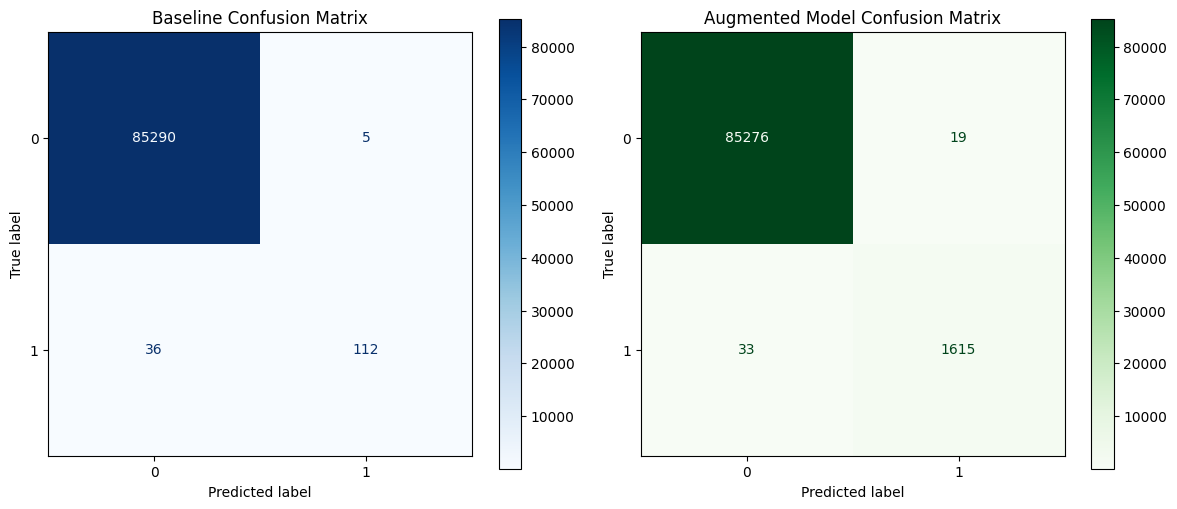

In [27]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

#Evaluate Baseline Model
y_pred_orig = clf_baseline.predict(X_test_orig)
y_prob_orig = clf_baseline.predict_proba(X_test_orig)[:, 1]

#Evaluate Augmented Model
y_pred_aug = clf_augmented.predict(X_test_aug)
y_prob_aug = clf_augmented.predict_proba(X_test_aug)[:, 1]

#Print Metrics Comparison
def print_metrics(name, y_true, y_pred, y_prob):
    print(f"--- {name} Metrics ---")
    print(f"Precision: {precision_score(y_true, y_pred):.2f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.2f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.2f}")
    print(f"AUC:       {roc_auc_score(y_true, y_prob):.2f}\n")

print_metrics("Baseline (Without Synthetic Data)", y_test_orig, y_pred_orig, y_prob_orig)
print_metrics("Augmented (With GenAI Data)", y_test_aug, y_pred_aug, y_prob_aug)

#Visualization: Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

cm_orig = confusion_matrix(y_test_orig, y_pred_orig)
disp_orig = ConfusionMatrixDisplay(confusion_matrix=cm_orig, display_labels=[0, 1])
disp_orig.plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Baseline Confusion Matrix')

cm_aug = confusion_matrix(y_test_aug, y_pred_aug)
disp_aug = ConfusionMatrixDisplay(confusion_matrix=cm_aug, display_labels=[0, 1])
disp_aug.plot(ax=ax[1], cmap='Greens')
ax[1].set_title('Augmented Model Confusion Matrix')

plt.tight_layout()
plt.show()

Cell 8: Final Evaluation & Visualizations

*Generate the final classification reports, confusion matrices, and ROC curves to prove the business impact (improved recall/F1-score)*

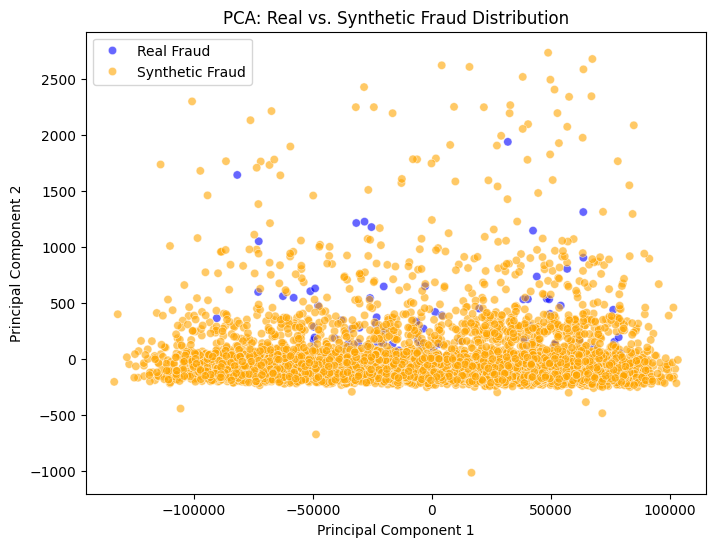

In [28]:
from sklearn.decomposition import PCA

#Prepare data for PCA (Ensure we only use features, drop the target 'Class')
real_fraud_features = fraud_data.drop('Class', axis=1)
synth_fraud_features = synthetic_fraud.drop('Class', axis=1)

#Add labels for the plot
real_fraud_features['Data Type'] = 'Real Fraud'
synth_fraud_features['Data Type'] = 'Synthetic Fraud'

#Combine and sample (for faster plotting)
combined_for_pca = pd.concat([real_fraud_features, synth_fraud_features])
pca_features = combined_for_pca.drop('Data Type', axis=1)
pca_labels = combined_for_pca['Data Type']

#Fit PCA (Reduce to 2 dimensions)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(pca_features)

combined_for_pca['pca-one'] = pca_results[:,0]
combined_for_pca['pca-two'] = pca_results[:,1]

#Plot the distributions
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="pca-one", y="pca-two",
    hue="Data Type",
    palette={"Real Fraud": "blue", "Synthetic Fraud": "orange"},
    data=combined_for_pca,
    alpha=0.6
)
plt.title('PCA: Real vs. Synthetic Fraud Distribution')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

READ.me

# Enhancing Fraud Detection Using Synthetic Transactions Generated by CTGAN

## Project Overview
This project tackles the severe class imbalance in credit card fraud detection by utilizing a Generative AI model (CTGAN) to synthesize realistic fraudulent transactions. By augmenting the real dataset with synthetic data, we improved the recall and overall F1-score of the Machine Learning classification model without exposing sensitive customer data.

## Tech Stack
* Python (Pandas, NumPy, Scikit-learn)
* Synthetic Data Vault (SDV) - CTGAN
* Random Forest Classifier
* Matplotlib & Seaborn

## Folder Structure
* `Notebooks/`: Contains the Jupyter notebooks for EDA, CTGAN Training, ML Training, and Visualizations.
* `Data/`: Contains the original, synthetic, and combined augmented datasets.
* `Model/`: Contains the serialized `.pkl` Random Forest model.
* `Final_Report.pdf`: Comprehensive business and technical report.
* `Fraud_Detection_Slides.pptx`: Presentation for stakeholders.

## Instructions to Run
1. Run `1_EDA.ipynb` to explore the initial dataset.
2. Run `2_CTGAN_Training.ipynb` to train the generator and synthesize data.
3. Run `3_Model_Training.ipynb` to evaluate the baseline vs. augmented ML models.

In [29]:
import joblib
joblib.dump(clf_augmented, 'fraud_model_rf.pkl')

['fraud_model_rf.pkl']